In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)


df = pd.read_csv('/content/superstore.csv')

print("Dataset Loaded Successfully")
df.head()


Q1: Data Cleaning

Q1 i) Count & Handle Missing Values

In [ ]:
print("Q1 i) Missing Values Count\n")
missing = df.isnull().sum()
print(missing[missing > 0])

# Handle missing values
df['Profit'] = df['Profit'].fillna(df['Profit'].median())
df['Sales'] = df['Sales'].fillna(df['Sales'].median())
df = df.ffill()

print("\nMissing values handled.")

Q1 ii) Deal with Duplicate Values

In [ ]:
print("\nQ1 ii) Duplicate Rows\n")
print("Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After:", df.duplicated().sum())


Q1 iii) Delete Unknown Columns

In [ ]:
print("\nQ1 iii) Removing Unknown Columns\n")

if 'ji_lu_shu' in df.columns:
    df.drop(columns=['ji_lu_shu'], inplace=True)
    print("Column 'ji_lu_shu' removed")
else:
    print("No unknown column found")


Q1 iv) Shape, Size & Datatypes

In [ ]:
print("\nQ1 iv) Dataset Info\n")
print("Shape:", df.shape)
print("\nData Types:\n")
df.dtypes


**Q2: Univariate Analysis (Numerical)**

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols


Histograms

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


Boxplots (Outliers)

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()


Insights

**Q3: Univariate Analysis (Categorical)**



In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols


Count Plots

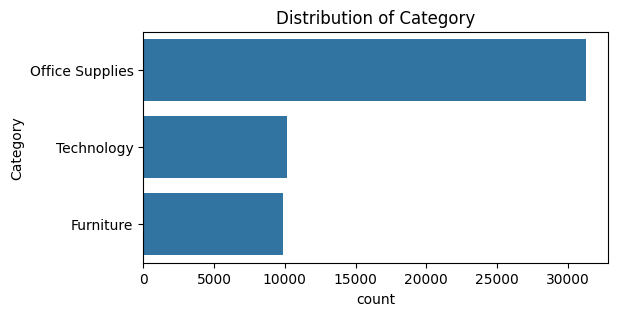

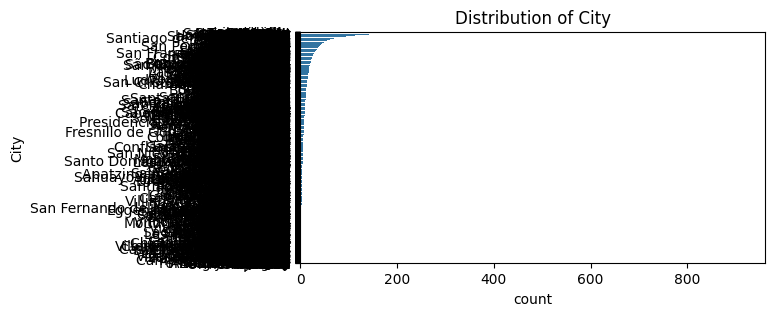

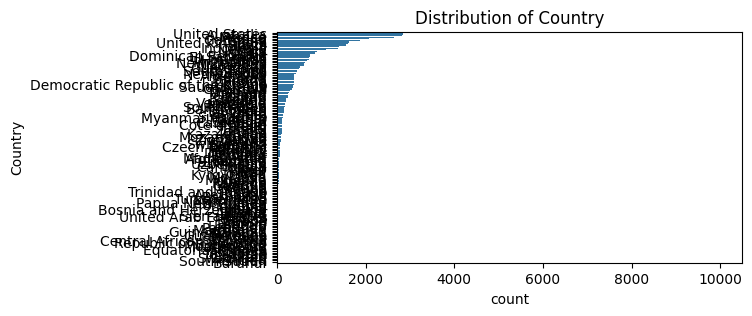

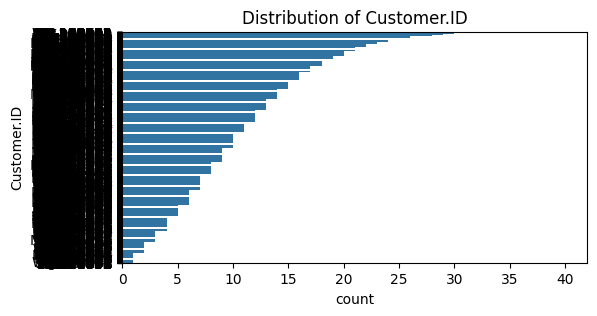

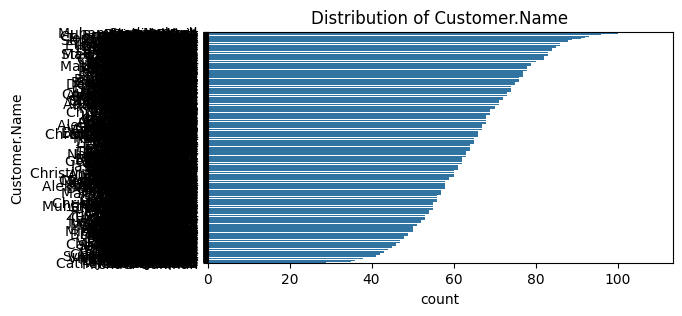

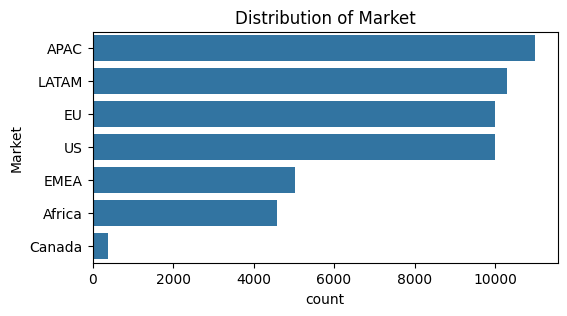

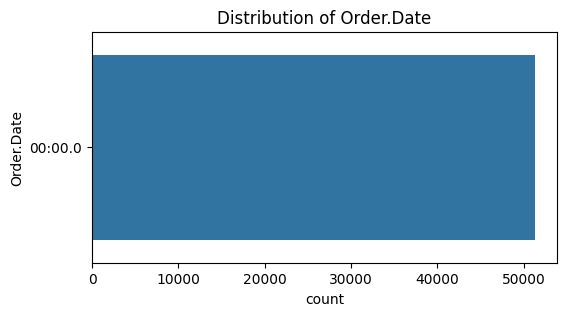

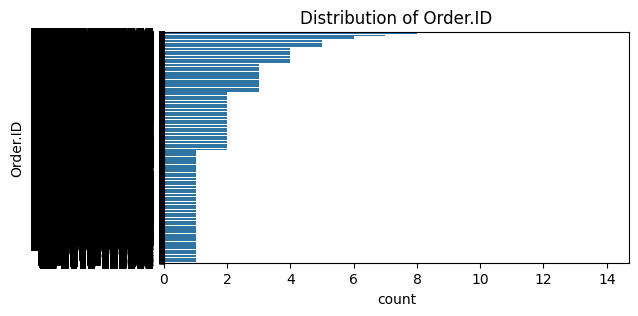

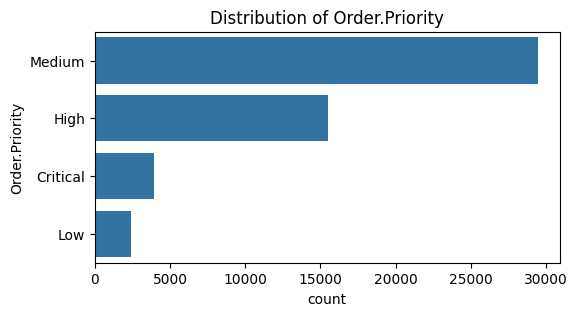

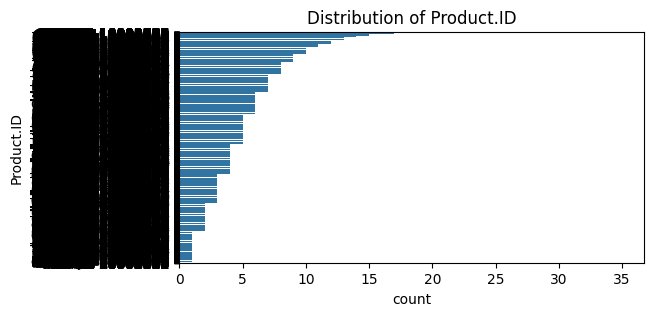

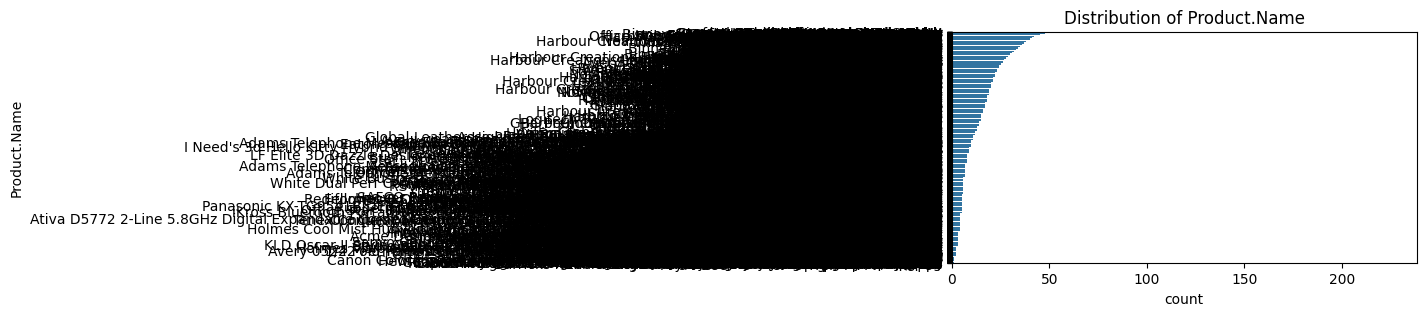

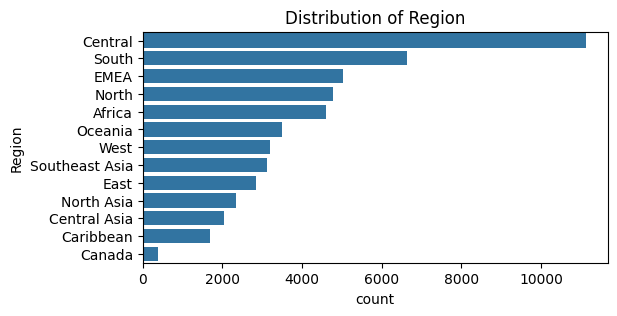

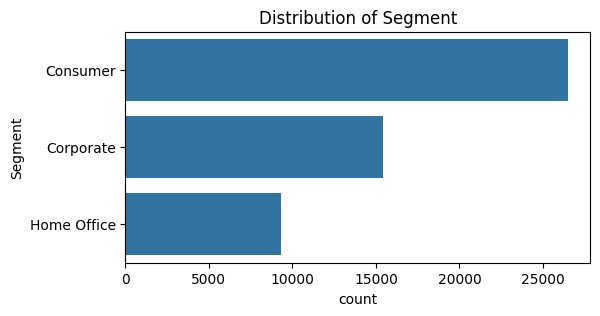

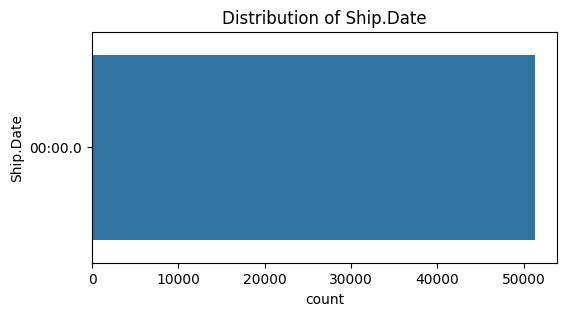

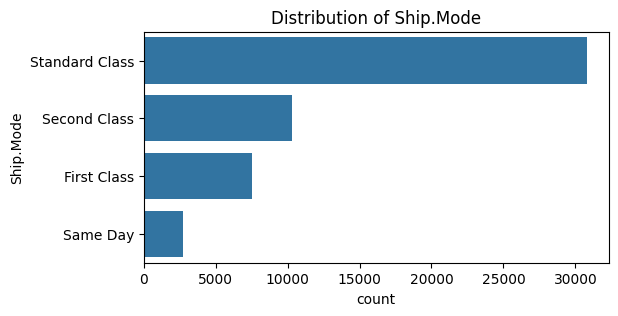

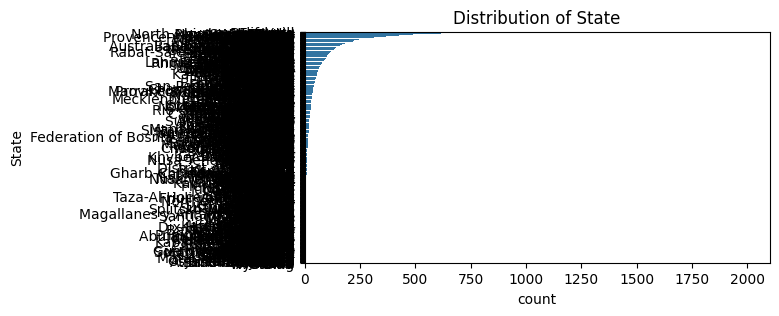

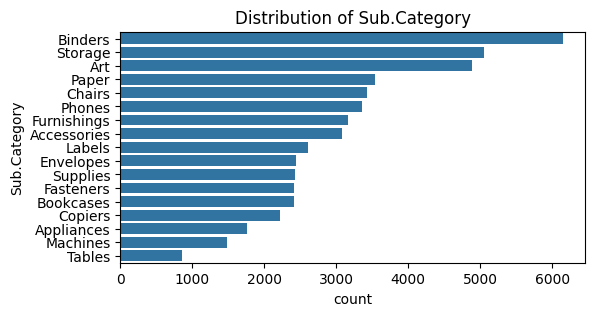

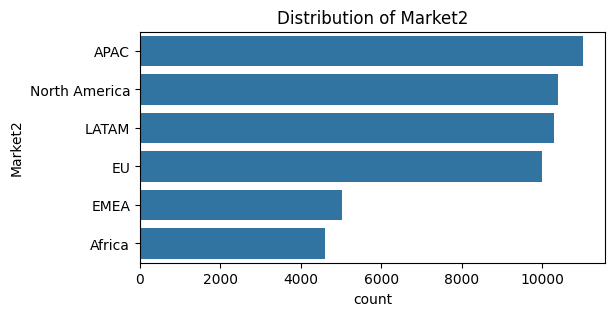

In [16]:
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()



Q3 Insights:
i. Inaccurate categorical features: customer_name, order_id (too unique)
ii. Customer Name causes high cardinality → poor for modeling
iii. Category distribution is skewed (Furniture dominates)
iv. One country dominates → geographic bias exists
v. Cities are highly concentrated in top metros


Q4: Bivariate Analysis (Numerical vs Numerical)

Correlation Heatmap

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 35760 (\N{CJK UNIFIED IDEOGRAPH-8BB0}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 24405 (\N{CJK UNIFIED IDEOGRAPH-5F55}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35760 (\N{CJK UNIFIED IDEOGRAPH-8BB0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24405 (\N{CJK UNIFIED IDEOGRAPH-5F55}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:15

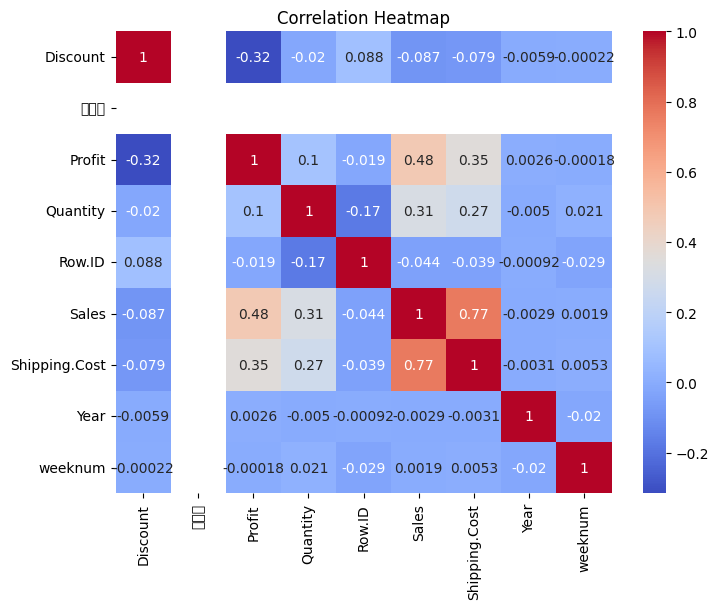

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Profit vs Sales

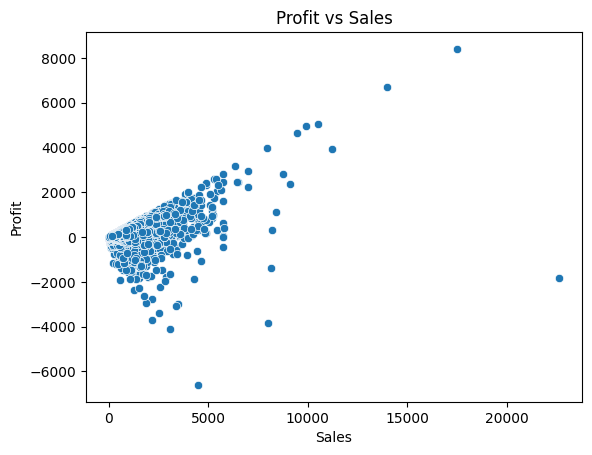

In [20]:
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Profit vs Sales')
plt.show()

Q4 Insights:
i. Strongest correlation: sales & profit
ii. Negative correlation: discount & profit
iii. Best predictors for profit: sales, discount, shipping_cost
iv. Time trend shows profit increases over years

**Q5: Categorical → Numerical Analysis**

Profit by Category

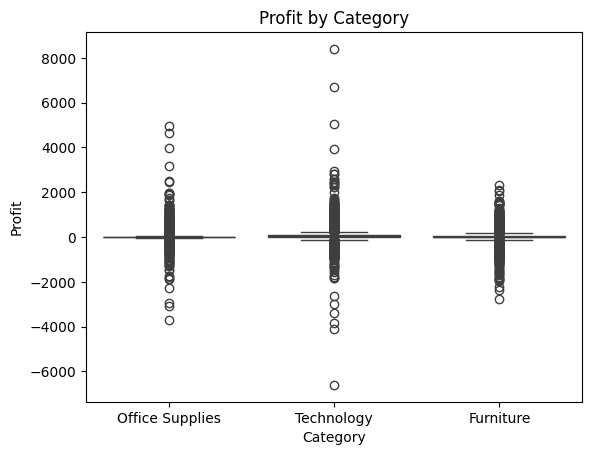

In [22]:
sns.boxplot(x='Category', y='Profit', data=df)
plt.title('Profit by Category')
plt.show()

Sales by Category

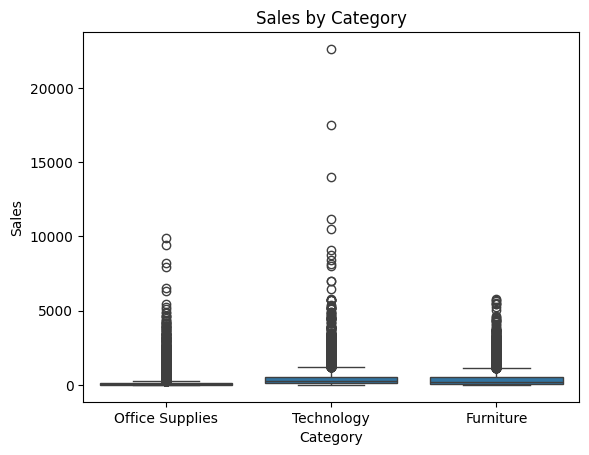

In [24]:
sns.boxplot(x='Category', y='Sales', data=df)
plt.title('Sales by Category')
plt.show()

Profit by Segment

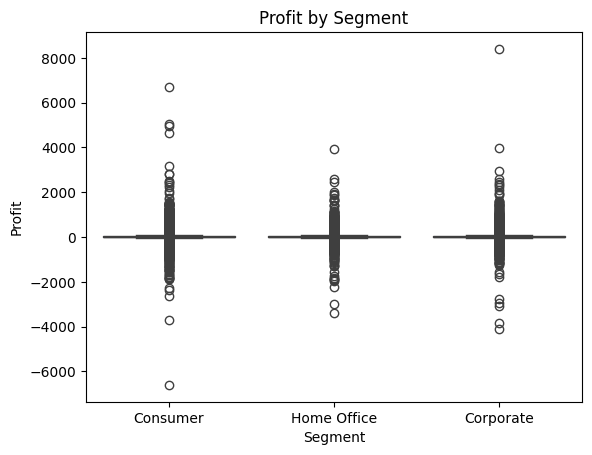

In [26]:
sns.boxplot(x='Segment', y='Profit', data=df)
plt.title('Profit by Segment')
plt.show()

Q5 Insights:
i. Highest median profit: Technology | Lowest: Furniture
ii. Highest sales ≠ highest profit
iii. Corporate segment shows most negative outliers
iv. Consumer has highest median sales but inconsistent profit